In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
matplotlib.rcParams['font.family'] = 'Nimbus Sans'
plt.rcParams['font.size'] = 9

In [2]:
# LOAD BOMBUS VISIT DATA WITH INTERVALS AND SPECIES ID, LIMIT TO CLOVER PERIOD
df = pd.read_csv('data/camtrap/processed/bombus_visit_durations.csv', parse_dates=["visit_start", "visit_end"])
bombus_visits_clover = df[df['visit_end'] < pd.Timestamp('2024-07-30')]

In [3]:
# CAMTRAP SPECIES COUNTS
bombus_visits_clover.value_counts('species')

species
vosnesenskii    173
fervidus         70
unk              31
griseocollis     13
nevadensis        2
appositus         1
mixtus            1
Name: count, dtype: int64

In [4]:
# PIVOT TO WIDE FORMAT OF COUNTS PER COLOR, COLS ARE COLORS
species_col_visits = pd.DataFrame(bombus_visits_clover[bombus_visits_clover['species'] != 'unk'].groupby(['species', 'color']).size()).reset_index()

species_col_visits.columns = ['species', 'color', 'visit_count']
species_col_wide = species_col_visits.pivot_table(
    index='species',
    columns='color',
    values='visit_count',
    fill_value=0
)

order = ['appositus', 'mixtus', 'nevadensis', 'griseocollis', 'fervidus', 'vosnesenskii']
# color_order = ['cnt', 'blv', 'grn', 'blu', 'yel']
color_order = ['yel','blu', 'grn','blv','cnt']
species_col_wide = species_col_wide[color_order]
species_col_wide = species_col_wide.reindex(order)

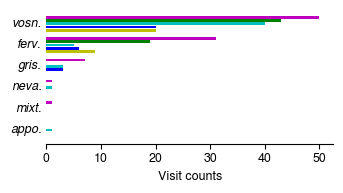

In [5]:
# PLOT SPECIES COUNTS PER STIMULUS TYPE
colors = ['yel', 'blu', 'blv', 'grn', 'cnt']
species = ['appo', 'mixt', 'neva', 'gris', 'ferv', 'vosn']

color_map = {
    'blu': 'b',
    'blv': 'c',
    'cnt': 'm',
    'grn': 'g',
    'yel': 'y'
}

x = np.arange(len(species))
width = 0.15

fig, ax = plt.subplots(figsize=(3.5, 2))
for i, color in enumerate(colors):
    ax.barh(x + i * width, species_col_wide[color], height=width*0.85, color=color_map[color])

ax.set_xlabel('Visit counts')
ax.set_yticks(x + width * len(colors) / 2)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(axis='y', which='both', length=0)
ax.set_yticklabels([f"{label}." for label in species], style='italic')

plt.tight_layout()
plt.savefig('figs/stimulus_species_counts.svg', format='svg')

In [6]:
# LOAD SPECIES COUNTS FOR CAMERA TRAPS, BLUE VANE TRAPS, AND HAND NETTING
cam_bombus_counts = bombus_visits_clover['species'].value_counts()

survey_data = pd.read_csv('data/pinned_specimens/specimen_records.csv')
bvt_data  = survey_data[survey_data['Collection method'] == 'vane trap'].reset_index(drop=True)
net_data  = survey_data[survey_data['Collection method'] == 'net'].reset_index(drop=True)

bvt_taxa = bvt_data[['Order ', 'Genus', 'Species', 'Sex', 'Caste']]
bvt_bombus_counts = bvt_taxa[bvt_taxa['Genus'] == 'Bombus']['Species'].value_counts()

net_taxa = net_data[['Order ', 'Genus', 'Species', 'Sex', 'Caste']]
net_bombus_counts = net_taxa[net_taxa['Genus'] == 'Bombus']['Species'].value_counts()

species_all = list(set(cam_bombus_counts.index).union(bvt_bombus_counts.index, net_bombus_counts.index))

species_all = [
 'caliginosus',
 'mixtus',
 'appositus',
 'nevadensis',
 'griseocollis',
 'fervidus',
 'vosnesenskii']

counts_s1 = [cam_bombus_counts[species] if species in cam_bombus_counts.index else 0 for species in species_all]
counts_s2 = [bvt_bombus_counts[species] if species in bvt_bombus_counts.index else 0 for species in species_all]
counts_s3 = [net_bombus_counts[species] if species in net_bombus_counts.index else 0 for species in species_all]
counts_s1_cnt = [species_col_wide['cnt'][species] if species in cam_bombus_counts.index else 0 for species in species_all]

# NORMALIZE COUNTS TO EFFORT
counts_s1n = [round(x/180, 2) for x in counts_s1] # PER TRAP DAY
counts_s2n = [round(x/16, 2) for x in counts_s2] # PER TRAP DAY
counts_s3n = [round(x/50, 2) for x in counts_s3] # PER SAMPLING MINUTE

df_counts = pd.DataFrame({
    'Species': species_all,
    'Camera': counts_s1,
    'BVT': counts_s2,
    'Net': counts_s3
})

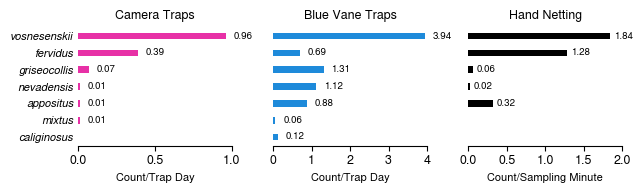

In [7]:
# PLOT METHODS COMPARISON WITH NORMALIZED COUNTS
bar_width = 0.4  
species_all_reversed = list(reversed(species_all))
y_pos = range(len(species_all_reversed))  
text_offset = .3

fig, axs = plt.subplots(1, 3, figsize=(6.5, 2), sharey=True)

axs[0].set_yticks(y_pos)
axs[0].invert_yaxis()
axs[0].set_xlabel('Count/Trap Day', size=8)
axs[0].set_xlim(0,1)
axs[0].set_xticks([0,0.5,1])
axs[0].set_title('Camera Traps', size=9)
bars0 = axs[0].barh(y_pos, list(reversed(counts_s1n)), height=bar_width, color='#e731a6ff')
for bar, count in zip(bars0, list(reversed(counts_s1n))):
    if count != 0:
        axs[0].text(
            bar.get_width() + .05,
            bar.get_y() + bar.get_height()/2,
            str(count),
            va='center',
            ha='left',
            size=7
        )

bars1 = axs[1].barh(y_pos, list(reversed(counts_s2n)), height=bar_width, color='#1e8adaff')
for bar, count in zip(bars1, list(reversed(counts_s2n))):
    if count != 0:
        axs[1].text(bar.get_width() + .2, bar.get_y() + bar.get_height()/2, str(count),
                    va='center', ha='left', size=7)
axs[1].set_yticks(y_pos)
axs[1].set_yticklabels([])  
axs[1].invert_yaxis()
axs[1].set_xlabel('Count/Trap Day', size=8)
axs[1].set_title('Blue Vane Traps', size=9)
axs[1].set_xlim(0,4)

bars2 = axs[2].barh(y_pos, list(reversed(counts_s3n)), height=bar_width, color='k')
for bar, count in zip(bars2, list(reversed(counts_s3n))):
    if count != 0:
        axs[2].text(bar.get_width() + .05, bar.get_y() + bar.get_height()/2, str(count),
                    va='center', ha='left', size=7)
        
axs[2].set_yticks(y_pos)
axs[2].set_yticklabels([]) 
axs[2].invert_yaxis()
axs[2].set_xlabel('Count/Sampling Minute', size=8)
axs[2].set_title('Hand Netting', size=9)
axs[2].set_xlim(0,2)

for ax in axs:
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='y', length=0)
    # ax.set_xlim(0, 4)
    # ax.set_xticks(range(0, 181, 60))


axs[0].set_yticklabels(
    [label for label in species_all_reversed],
    style='italic',
    size=8
)
plt.tight_layout()
plt.savefig('figs/methods_comparison_separated_norm.svg', format='svg')

In [8]:
# EXPORT TO R
inext_ready = [counts_s1_cnt, counts_s2, counts_s3]

%load_ext rpy2.ipython
%R -i inext_ready

In [9]:
%%R
library(iNEXT)

out_df <- iNEXT(inext_ready, q = c(0,1,2), datatype = "abundance", nboot=1000, endpoint = 3 * max(sapply(inext_ready, sum)))
asy_est <- out_df$AsyEst
datainfo <- out_df$DataInfo
size_est <- out_df$iNextEst$size_based
coverage_est <- out_df$iNextEst$coverage_based

In [10]:
%R -o datainfo
%R -o asy_est
%R -o size_est
%R -o coverage_est

In [11]:
div_dict = {"Species richness":0, "Shannon diversity":1, "Simpson diversity":2}
assem_dict = {"assemblage1":"cam", "assemblage2":"bvt", "assemblage3":"net"}
asy_est['Diversity'] = asy_est['Diversity'].replace(div_dict)

for dataframe in [asy_est, datainfo, size_est, coverage_est]:
    dataframe['Assemblage'] = dataframe['Assemblage'].replace(assem_dict)

/tmp/ipykernel_2727028/563144823.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  asy_est['Diversity'] = asy_est['Diversity'].replace(div_dict)


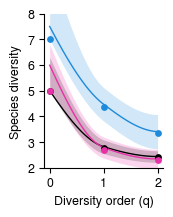

In [12]:
import numpy as np
from scipy.interpolate import PchipInterpolator

method_color_map = {'cam':'#e731a6ff', 'bvt':'#1e8adaff', 'net':'k'}
order = ["net", "cam", "bvt"] 

fig, ax = plt.subplots(figsize=(1.8,2.25))

for assemblage in order:
    subdf = asy_est[asy_est["Assemblage"] == assemblage]
    x = subdf["Diversity"].values.astype(float)
    y = subdf["Estimator"].values.astype(float)
    lcl = subdf["LCL"].values.astype(float)
    ucl = subdf["UCL"].values.astype(float)
    obs = subdf["Observed"].values.astype(float)

    color = method_color_map.get(assemblage, "k")
    x_smooth = np.linspace(x.min(), x.max(), 200)
    f_est = PchipInterpolator(x, y)
    f_lcl = PchipInterpolator(x, lcl)
    f_ucl = PchipInterpolator(x, ucl)

    y_smooth = f_est(x_smooth)
    lcl_smooth = f_lcl(x_smooth)
    ucl_smooth = f_ucl(x_smooth)

    ax.plot(x_smooth, y_smooth, color=color, linewidth=1)
    ax.fill_between(x_smooth, lcl_smooth, ucl_smooth, color=color, alpha=0.2, linewidth=0)
    # ax.plot(x, obs, color=color, linestyle=":", alpha=1, label=f"{assemblage} (Observed)", marker='o', markersize=3, zorder=4)
    # ax.scatter(x, obs, edgecolor=color, facecolor='none', marker='o', s=15, zorder=4)
    ax.scatter(x, obs, color=color, marker='o', s=15, zorder=4)

ax.set_xlabel("Diversity order (q)")
ax.set_ylabel("Species diversity")
ax.set_xticks([0,1,2], labels=[0,1,2])
ax.set_ylim(2,8)


plt.tight_layout()
plt.savefig('figs/asyest_methods.svg', format='svg')


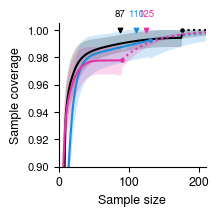

In [13]:
from scipy.optimize import brentq  # root-finding for inverse lookup

fig, ax = plt.subplots(figsize=(2.25,2.25))
order = ["net", "bvt", "cam"] 
order_q = 0
df_filtered = size_est[size_est['Order.q'] == order_q]

coverage_targets = [0.99]

for assemblage in order:
    subdf = df_filtered[df_filtered["Assemblage"] == assemblage].copy()
    color = method_color_map.get(assemblage, "gray")

    if subdf.empty:
        continue

    subdf = subdf[["Method","m","SC","SC.LCL","SC.UCL"]].dropna()
    subdf = subdf.sort_values("m").drop_duplicates(subset=["m"], keep="last")

    if "Observed" not in subdf["Method"].values:
        continue

    obs_m = subdf[subdf["Method"]=="Observed"]["m"].iloc[0]

    f_y = PchipInterpolator(subdf["m"], subdf["SC"])
    f_lcl = PchipInterpolator(subdf["m"], subdf["SC.LCL"])
    f_ucl = PchipInterpolator(subdf["m"], subdf["SC.UCL"])

    x_smooth = np.linspace(subdf["m"].min(), subdf["m"].max(), 400)
    y_smooth = f_y(x_smooth)
    lcl_smooth = f_lcl(x_smooth)
    ucl_smooth = f_ucl(x_smooth)

    mask_rare = x_smooth <= obs_m
    mask_extra = x_smooth >= obs_m

    ax.plot(x_smooth[mask_rare], y_smooth[mask_rare], color=color, label=assemblage)
    ax.plot(x_smooth[mask_extra], y_smooth[mask_extra], color=color, linestyle="dotted")
    ax.fill_between(x_smooth, lcl_smooth, ucl_smooth, color=color, alpha=0.2, linewidth=0)

    obs = subdf[subdf["Method"] == "Observed"]
    ax.scatter(obs["m"], obs["SC"], color=color, marker="o", s=5, zorder=3)

    for target in coverage_targets:
        try:
            m_target = brentq(lambda xx: f_y(xx) - target, subdf["m"].min(), subdf["m"].max())
            ax.scatter(m_target, 1, color=color, marker="v", zorder=4, linewidths=1, s=10)
            if assemblage == 'bvt':
                ax.text(m_target, target + 0.02, f"{int(round(m_target))}", color=color, fontsize=7, ha="center")
            else:
                ax.text(m_target, target + 0.02, f"{int(round(m_target))}", color=color, fontsize=7, ha="center")
        except ValueError:
            pass


ax.set_ylim(0.90, 1.005)
ax.set_yticks(np.arange(0.9, 1.02, 0.02))
ax.set_yticklabels([f"{y:.2f}" for y in np.arange(0.9, 1.02, 0.02)], size=8)
ax.set_ylabel("Sample coverage") 
ax.set_xlim(0,210)
ax.set_xticks([0,100,200])
ax.set_xlabel("Sample size")
plt.tight_layout()
plt.savefig('figs/coverage_est.svg', format='svg')

In [14]:
# GET OBSERVED VALUES FOR EACH Q ORDER
size_est[(size_est['Assemblage'] == 'net') & (size_est['Method'] == 'Observed')]

,Assemblage,m,Method,Order.q,qD,qD.LCL,qD.UCL,SC,SC.LCL,SC.UCL
260,net,176.0,Observed,0.0,5.000000,3.957552,6.042448,1.0,0.993858,1.0
300,net,176.0,Observed,1.0,2.783532,2.499395,3.067670,1.0,0.993858,1.0
340,net,176.0,Observed,2.0,2.415094,2.183360,2.646829,1.0,0.993858,1.0
